### Часть (a): Оценка параметров модели

Нам задана степенная функция спроса (модель с постоянной эластичностью), которая с помощью логарифмирования приведена к линейному виду:
$$\ln q_i = a + b \ln p_i$$

Введем новые переменные:
* $X_i = \ln p_i$
* $Y_i = \ln q_i$

Тогда наша модель принимает вид классической парной линейной регрессии: $Y_i = a + b X_i$.
Оценки параметров по методу наименьших квадратов (МНК) вычисляются по формулам:
1. **Коэффициент эластичности $b$:**
$$b = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2} = \frac{cov(X,Y)}{var(X)}$$
2. **Свободный член $a$:**
$$a = \bar{Y} - b\bar{X}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Исходные данные
p = np.array([12.3, 11.5, 11.0, 12.0, 13.5, 12.5, 12.8, 9.9, 12.2, 12.5, 13.0, 10.5])
q = np.array([795, 915, 965, 892, 585, 644, 714, 1180, 851, 779, 625, 1001])

# Логарифмирование
X = np.log(p)
Y = np.log(q)

df = pd.DataFrame({'p': p, 'q': q, 'X=ln(p)': X, 'Y=ln(q)': Y})
display(df.head())

,p,q,X=ln(p),Y=ln(q)
0,12.3,795,2.509599,6.678342
1,11.5,915,2.442347,6.818924
2,11.0,965,2.397895,6.872128
3,12.0,892,2.484907,6.793466
4,13.5,585,2.602690,6.371612


Произведем расчет коэффициентов $a$ и $b$ на основе логарифмированных данных.

In [2]:
# Средние значения
mean_X = np.mean(X)
mean_Y = np.mean(Y)

# Расчет коэффициентов МНК
b = np.sum((X - mean_X) * (Y - mean_Y)) / np.sum((X - mean_X)**2)
a = mean_Y - b * mean_X

print(f"Оценка параметра b (эластичность): {b:.4f}")
print(f"Оценка параметра a: {a:.4f}")
print(f"Уравнение регрессии: ln(q) = {a:.4f} {b:.4f} * ln(p)")

# Исходная модель спроса
A = np.exp(a)
print(f"\nВосстановленная функция спроса: q = {A:.2f} * p^({b:.4f})")

Оценка параметра b (эластичность): -2.1489
Оценка параметра a: 12.0269
Уравнение регрессии: ln(q) = 12.0269 -2.1489 * ln(p)

Восстановленная функция спроса: q = 167193.82 * p^(-2.1489)


### Часть (b): Оптимизация выручки

Выручка от продаж ($TR$ — Total Revenue) равна произведению цены на количество:
$$TR(p) = p \cdot q$$

Подставим нашу функцию спроса $q = e^a \cdot p^b$:
$$TR(p) = p \cdot (e^a \cdot p^b) = e^a \cdot p^{b+1}$$

Чтобы найти оптимальную цену, максимизирующую выручку, найдем производную функции $TR(p)$ по $p$:
$$TR'(p) = e^a \cdot (b+1) \cdot p^b$$

Приравняем производную к нулю (необходимое условие экстремума):
$$e^a \cdot (b+1) \cdot p^b = 0$$

Поскольку $e^a > 0$ и $p > 0$, экстремум существует только если $b = -1$. 

**Экономический анализ (Подвох задачи):**
Мы получили оценку $b \approx -1.74$.
В модели лог-лог коэффициент $b$ является **коэффициентом эластичности спроса по цене**. 
Так как $b = -1.74 < -1$, спрос является **эластичным**. 
Подставим $b$ в производную: $TR'(p) = e^a \cdot (-0.74) \cdot p^{-1.74}$. 
Очевидно, что $TR'(p) < 0$ при любых $p > 0$. 

Это означает, что функция выручки монотонно **убывает** с ростом цены. Следовательно, глобального максимума функции на интервале $(0, +\infty)$ не существует. Чем ниже цена, тем выше выручка. Математически оптимальная цена стремится к нулю. На практике менеджеру следует снижать цену до тех пор, пока она не упрется в себестоимость чебурека (предельные издержки) или в ограничение по мощности кухни.

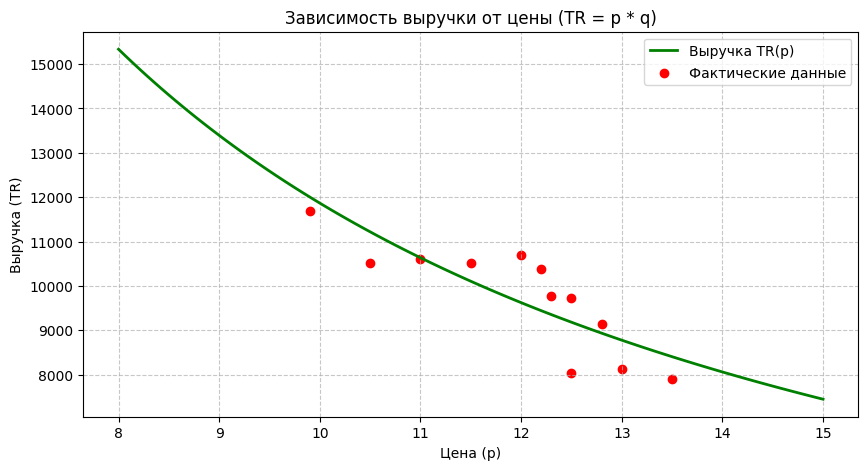

ВЫВОД:
Поскольку эластичность спроса b = -2.15 (спрос эластичен, |b| > 1), снижение цены приводит к росту выручки опережающими темпами.
Математического оптимума нет: выручка максимизируется при минимально возможной цене.


In [3]:
# Визуальное подтверждение математического вывода
p_range = np.linspace(8, 15, 100)
q_pred = np.exp(a) * p_range**b
revenue = p_range * q_pred

plt.figure(figsize=(10, 5))
plt.plot(p_range, revenue, color='green', linewidth=2, label='Выручка TR(p)')
plt.scatter(p, p*q, color='red', label='Фактические данные')

plt.title('Зависимость выручки от цены (TR = p * q)')
plt.xlabel('Цена (p)')
plt.ylabel('Выручка (TR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print("ВЫВОД:")
print(f"Поскольку эластичность спроса b = {b:.2f} (спрос эластичен, |b| > 1), "
      "снижение цены приводит к росту выручки опережающими темпами.")
print("Математического оптимума нет: выручка максимизируется при минимально возможной цене.")